# Coupe d'Afrique des Nations en Data Science 2025

**Equipe** : DataStorm

**Auteur** : Alimi SARA GANKOU

**Organisateur** : Data Afrique Hub

Ce projet est dans le cadre de la CANSD 2025, cette partie est la partie réalisée par Alimi SARA GANKOU pour l'équipe **DataStorm**.

Il consiste à créer un modèle de prédiction du risque de **défaut de crédit** basé sur des données d’historique de prêts. 

**Variable cible** : flag  (1 pour défaut et 0 pour remboursement correct)

**id** : identifiant unique de la demande de prêt

**rn:**  numéro de série du produit de crédit dans l’historique

**Nombre d'observations**: 17 millions

**Nombres de Variables** : 62

## Import

**Modèle final retenu**: LightGBM

**Metric**: ROC AUC

**Scarling**: MinMax. Certaines catégorielles étant non-normalisées

**linregress**: Pour créer une variable de tendance dans le feature engenering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score

## Chargement des Données

**train** : Les données données par les organisateurs (privées) pour l'entrainement et l'évaluation de nos modèles en interne

**test**: Les données tests fournies par les organisateurs sans la variable cible, pour tester nos modèles à leur niveau

In [2]:
# Données d'entrainement et d'évaluation interne
train = pd.read_parquet("/kaggle/input/dataset/dataset/train.parquet") 

# Données pour l'évaluation des modèles par l'équipe organisatrice
test= pd.read_parquet("/kaggle/input/dataset/dataset/test.parquet")

In [3]:
train.shape

(17659833, 62)

Pour faute de matérielle, nous allons travailler sur un sous-échantillon (7M) des 17M d'observations

In [4]:
# Sous-échantillon sur lequel nous allons travailler
df = train.sample(n=7_000_000, random_state=42)
df.head(15)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
5659802,2773981,20,4,8,13,0,16,7,6,2,...,3,3,4,1,3,4,1,0,0,0
13091988,2093107,2,2,5,16,9,7,15,12,2,...,3,3,4,1,3,4,1,0,0,0
4111548,719012,7,13,17,17,8,16,11,14,2,...,3,3,4,1,3,3,1,0,1,0
4804348,2146713,6,8,11,0,13,13,13,12,2,...,0,0,1,1,3,3,1,0,0,0
3859210,2912327,2,8,17,8,11,4,9,12,2,...,3,3,4,1,3,4,1,0,0,0
3374859,2952537,1,16,12,8,11,4,9,5,2,...,3,3,4,1,3,4,1,0,0,0
11819332,2773498,12,2,9,14,15,14,15,0,0,...,3,3,4,1,3,4,1,0,0,0
8805403,465545,9,5,2,0,8,14,11,17,2,...,0,0,1,1,2,3,1,0,1,0
4550099,2332272,7,6,3,9,12,3,10,13,2,...,3,3,4,1,3,4,1,0,0,0
6680456,2967057,8,1,0,16,9,7,15,3,2,...,3,3,4,1,3,4,1,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7000000 entries, 5659802 to 6008476
Data columns (total 62 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int32
 1   rn                             int8 
 2   pre_since_opened               int8 
 3   pre_since_confirmed            int8 
 4   pre_pterm                      int8 
 5   pre_fterm                      int8 
 6   pre_till_pclose                int8 
 7   pre_till_fclose                int8 
 8   pre_loans_credit_limit         int8 
 9   pre_loans_next_pay_summ        int8 
 10  pre_loans_outstanding          int8 
 11  pre_loans_total_overdue        int8 
 12  pre_loans_max_overdue_sum      int8 
 13  pre_loans_credit_cost_rate     int8 
 14  pre_loans5                     int8 
 15  pre_loans530                   int8 
 16  pre_loans3060                  int8 
 17  pre_loans6090                  int8 
 18  pre_loans90                    int8 
 19 

In [6]:
# Séparation de données en données d'entrainement et données test
X = df.drop(columns=['id', 'flag', 'rn'])
y = df['flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Analyse Exploratoire (EDA)

In [7]:
# Statistique descriptive des variables explicatives
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
pre_since_opened,5600000.0,9.363547,5.776046,0.0,4.0,9.0,14.0,19.0
pre_since_confirmed,5600000.0,8.224254,4.713740,0.0,4.0,9.0,12.0,17.0
pre_pterm,5600000.0,8.364413,5.325160,0.0,4.0,8.0,14.0,17.0
pre_fterm,5600000.0,8.331731,4.477636,0.0,6.0,8.0,12.0,16.0
pre_till_pclose,5600000.0,7.139732,5.151849,0.0,2.0,7.0,12.0,16.0
pre_till_fclose,5600000.0,8.360398,4.224596,0.0,5.0,10.0,11.0,15.0
pre_loans_credit_limit,5600000.0,9.675439,5.827444,0.0,5.0,10.0,15.0,19.0
pre_loans_next_pay_summ,5600000.0,2.364096,1.310260,0.0,2.0,2.0,2.0,6.0
pre_loans_outstanding,5600000.0,2.996060,0.710455,1.0,3.0,3.0,3.0,5.0
pre_loans_total_overdue,5600000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


Certaines variables de payement (enc_paym) sont mal codées. Au lieu de 0 à 3, elles sont de 1 à 4

La variable "pre_loans_total_overdue" a un petit souci, elle est nulle partout.

In [8]:
# Distribution de la variable cible
distribution = y_train.value_counts(normalize=True)
distribution

flag
0    0.966389
1    0.033611
Name: proportion, dtype: float64

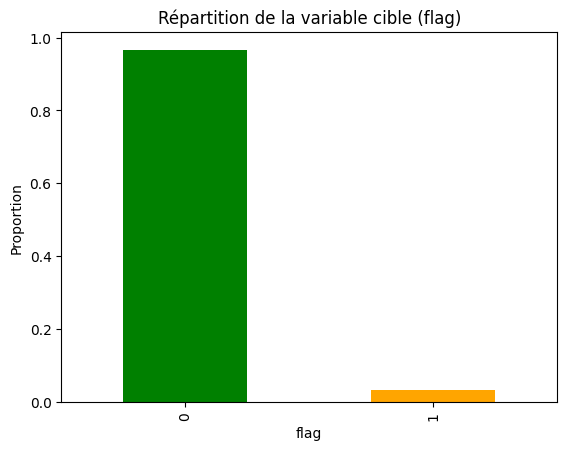

In [9]:
# Visualisation graphique
distribution.plot(kind='bar', color=['green', 'orange'])
plt.title("Répartition de la variable cible (flag)")
plt.ylabel("Proportion")
plt.show()

In [10]:
# Corrélations entre les variables explicatives
corr_matrix = X_train.corr(method='pearson')

In [11]:
# liste des variables dont la corrélation est supérieure 0.7
seuil = 0.7

len_matrix_corr = len(corr_matrix.columns)# la longueur des columns à parcourir pour ajouter ou non leur corrélation
corr_elevee = [] # la liste des variables et leur corrélation

for i in range(len_matrix_corr):
    for j in range(i+1, len_matrix_corr):
        val = corr_matrix.iloc[i, j]
        if abs(val) > seuil:
            corr_elevee.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

# Tri par ordre décroissante
corr_elevee = sorted(corr_elevee, key=lambda x: abs(x[2]), reverse=True)

# Affichage des corrélations
for var1, var2, val in corr_elevee:
    print(f"{var1} - {var2} : corrélation = {val:.2f}")


enc_paym_20 - enc_paym_21 : corrélation = 0.96
enc_paym_21 - enc_paym_22 : corrélation = 0.96
enc_paym_19 - enc_paym_20 : corrélation = 0.96
enc_paym_22 - enc_paym_23 : corrélation = 0.96
enc_paym_16 - enc_paym_17 : corrélation = 0.96
enc_paym_18 - enc_paym_19 : corrélation = 0.96
enc_paym_15 - enc_paym_16 : corrélation = 0.96
enc_paym_17 - enc_paym_18 : corrélation = 0.95
enc_paym_14 - enc_paym_15 : corrélation = 0.95
enc_paym_13 - enc_paym_14 : corrélation = 0.94
enc_paym_20 - enc_paym_22 : corrélation = 0.93
enc_paym_19 - enc_paym_21 : corrélation = 0.93
enc_paym_21 - enc_paym_23 : corrélation = 0.93
enc_paym_18 - enc_paym_20 : corrélation = 0.92
enc_paym_15 - enc_paym_17 : corrélation = 0.92
enc_paym_16 - enc_paym_18 : corrélation = 0.92
enc_paym_17 - enc_paym_19 : corrélation = 0.92
enc_paym_14 - enc_paym_16 : corrélation = 0.92
enc_paym_8 - enc_paym_9 : corrélation = 0.91
enc_paym_7 - enc_paym_8 : corrélation = 0.91
enc_paym_13 - enc_paym_15 : corrélation = 0.91
enc_paym_12 - enc

La plupart des variables fortement corrélées sont des variables de payement (enc_paym).


## Feature Engineering

Vu les corrélations fortes entre les variables de payement, nous allons nous concentrer dessus pour faire sortir des nouvelles variables qui fournissent un maximum d'information que contiennent ces variables

La variable "pre_loans_total_overdue" étant null partout sans aucune information là dessus, il est préférable de l'enlever

In [12]:
# Suppression de la colonne "pre_loans_total_overdue"
def supprimer_colonne_nulle(X):
    return X.drop(columns=['pre_loans_total_overdue'])

X_train = supprimer_colonne_nulle(X_train)
X_test  = supprimer_colonne_nulle(X_test)

In [13]:
# La fonction de création d'une pente de regression entre les 25 enc_paym
def tendance_lineaire(ligne):
    x = np.arange(len(ligne))
    pente, intercept, r_value, p_value, std_err = linregress(x, ligne.values)
    return pente

In [14]:
def ajout_features_paiements(X_train, X_test):

    # Liste des vaiables de paiements 
    enc_cols = [f'enc_paym_{i}' for i in range(25)
                if f'enc_paym_{i}' in X_train.columns] 

    #  Normalisation des colonnes hors échelle (0 pour le min et 3 pour le max)
    cols_scale = [c for c in ['enc_paym_20', 'enc_paym_24'] if c in enc_cols]
    scaler = MinMaxScaler(feature_range=(0, 3))
    X_train[cols_scale] = scaler.fit_transform(X_train[cols_scale])
    X_test[cols_scale]  = scaler.transform(X_test[cols_scale])

    # Créations des nouvelles features en se basant sur les enc_payms
    def news_features_enc_paym(X, enc_cols):
        enc = X[enc_cols]
        X['enc_paym_mean']           = enc.mean(axis=1)
        X['enc_paym_sum']            = enc.sum(axis=1)
        X['enc_paym_var']            = enc.var(axis=1)
        X['enc_paym_min']            = enc.min(axis=1)
        X['enc_paym_max']            = enc.max(axis=1)
        X['enc_paym_num_late_months'] = (enc > 0).sum(axis=1)
        X['enc_paym_trend']          = enc.apply(tendance_lineaire, axis=1)
        return X

    X_train = news_features_enc_paym(X_train, enc_cols)
    X_test  = news_features_enc_paym(X_test,  enc_cols)

    return X_train, X_test

In [15]:
X_train, X_test = ajout_features_paiements(X_train, X_test)

## Entrainement du modèle

In [16]:
model = LGBMClassifier(random_state=42, is_unbalance=True, n_estimators=100)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 188222, number of negative: 5411778
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.717316 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1001
[LightGBM] [Info] Number of data points in the train set: 5600000, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033611 -> initscore=-3.358711
[LightGBM] [Info] Start training from score -3.358711


LGBMClassifier(is_unbalance=True, random_state=42)

## Evaluation

In [17]:
# Evaluation du modèle sur les données test

y_pred = model.predict_proba(X_test)[:, 1]
print("ROC AUC sur test interne :", roc_auc_score(y_test, y_pred))


ROC AUC sur test interne : 0.6411285343145015


## Application du modèle sur les données tests des organisateurs

On applique maintenant le modèle sur les données test des organisateurs, exporter les résultats pour une évaluation à leur niveau



In [18]:
X_test_final = test.drop(columns=["id", "rn", "id_x_rn"])
X_test_final = supprimer_colonne_nulle(X_test_final)
X_train, X_test_final = ajout_features_paiements(X_train, X_test_final)

In [19]:
# Application du modèle
test_preds = model.predict_proba(X_test_final)[:, 1]

Le code suivant a été donné par les organisateurs pour l'exportation et l'évaluation de nos modèles

In [20]:
test_ids = pd.read_parquet("/kaggle/input/dataset/dataset/test.parquet", columns=["id_x_rn"])


In [21]:
ss = pd.DataFrame({
    "id": test_ids["id_x_rn"],    
    "target": test_preds          
})

In [22]:
ss.target.value_counts()

target
0.578629    182
0.586438    145
0.587610    137
0.600860    132
0.557295    127
           ... 
0.541108      1
0.691441      1
0.342354      1
0.404605      1
0.612956      1
Name: count, Length: 521135, dtype: int64

In [23]:
ss.to_parquet("/kaggle/working/submission_lgb.parquet", index=False)